# Policy-Gradient RL-SAT on Long-Tailed CIFAR-10

This notebook implements **Reinforcement Learning with Policy Gradients** combined with **Self-Adaptive Training (SAT)** for long-tailed classification.

**Key Innovation:**
- **Policy Network**: Learns optimal sample weighting and curriculum scheduling
- **Dynamic Reweighting**: Adjusts loss weights per sample based on current model state
- **Curriculum Learning**: Progressively shifts focus from easy (head) to hard (tail) classes
- **State Representation**: Encodes per-class accuracy, confidence, and training progress
- **Reward Signal**: Combines balanced accuracy and worst-group improvement

**Addresses SAT Weaknesses:**
1. ✅ Class imbalance → Dynamic reweighting prioritizes tail classes
2. ✅ Poor tail learning → Curriculum gradually increases tail class importance
3. ✅ Feature quality → RL explores better training strategies
4. ✅ Catastrophic forgetting → Policy learns when to revisit classes

**Policy Network Architecture:**
```
State: [10 class accuracies, 10 class confidences, 10 class losses, epoch progress]
       → MLP(40 → 128 → 64 → 10) → 
Action: [10 class weights] (softmax normalized)
Reward: Δ(balanced_acc) + 2×Δ(worst_acc) - 0.1×entropy
```

**Settings:**
- Architecture: VGG-16 with Batch Normalization
- Dataset: CIFAR-10 Long-Tailed (IR=100)
- RL Algorithm: REINFORCE with baseline
- Training: 300 epochs with policy updates every 5 epochs
- Exploration: ε-greedy with decay

## 1. Setup and Imports

In [1]:
import os
import time
import random
import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.distributions import Categorical
from PIL import Image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# ============================================================================
# EMBEDDED UTILITY CLASSES (Same as baseline)
# ============================================================================

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res


class SelfAdaptiveTraining():
    """Self-Adaptive Training loss function with weighted samples"""
    def __init__(self, num_examples=50000, num_classes=10, mom=0.9):
        self.prob_history = torch.zeros(num_examples, num_classes)
        self.updated = torch.zeros(num_examples, dtype=torch.int)
        self.mom = mom
        self.num_classes = num_classes

    def _update_prob(self, prob, index, y):
        # Move index to CPU for accessing CPU tensors
        index_cpu = index.cpu() if index.is_cuda else index
        
        onehot = torch.zeros_like(prob)
        onehot[torch.arange(y.shape[0]), y] = 1
        prob_history = self.prob_history[index_cpu].clone().to(prob.device)

        cond = (self.updated[index_cpu] == 1).to(prob.device).unsqueeze(-1).expand_as(prob)
        prob_mom = torch.where(cond, prob_history, onehot)

        prob_mom = self.mom * prob_mom + (1 - self.mom) * prob

        self.updated[index_cpu] = 1
        self.prob_history[index_cpu] = prob_mom.to(self.prob_history.device)

        return prob_mom

    def __call__(self, logits, y, index, sample_weights=None):
        """
        Args:
            sample_weights: Per-sample loss weights from RL policy (optional)
        """
        prob = F.softmax(logits.detach()[:, :self.num_classes], dim=1)
        prob = self._update_prob(prob, index, y)

        soft_label = torch.zeros_like(logits)
        soft_label[torch.arange(y.shape[0]), y] = prob[torch.arange(y.shape[0]), y]
        soft_label[:, -1] = 1 - prob[torch.arange(y.shape[0]), y]
        soft_label = F.normalize(soft_label, dim=1, p=1)
        loss = torch.sum(-F.log_softmax(logits, dim=1) * soft_label, dim=1)
        
        # Apply sample weights from RL policy
        if sample_weights is not None:
            loss = loss * sample_weights
        
        return torch.mean(loss)


# ============================================================================
# VGG-16 MODEL (Same as baseline)
# ============================================================================

class VGG(nn.Module):
    def __init__(self, features, num_classes=1000, input_size=32):
        super(VGG, self).__init__()
        self.features = features
        if input_size == 32:
            self.classifier = nn.Sequential(
                nn.Linear(512, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        elif input_size == 64:
            self.classifier = nn.Sequential(
                nn.Linear(2048, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                n = m.weight.size(1)
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


def make_layers(cfg, batch_norm=False):
    layers = []
    in_channels = 3
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        elif type(v) == int:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.ReLU(inplace=True), nn.BatchNorm2d(v)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
        elif type(v) == float:
            layers += [nn.Dropout2d(v)]
    return nn.Sequential(*layers)


cfg_vgg16 = {
    'D': [64, 0.3, 64, 'M', 128, 0.4, 128, 'M', 256, 0.4, 256, 0.4, 256, 'M',
          512, 0.4, 512, 0.4, 512, 'M', 512, 0.4, 512, 0.4, 512, 'M', 0.5]
}


def vgg16_bn(num_classes=1000, input_size=32, **kwargs):
    """VGG 16-layer model with batch normalization"""
    model = VGG(make_layers(cfg_vgg16['D'], batch_norm=True), 
                num_classes=num_classes, input_size=input_size, **kwargs)
    return model


print("✅ All utility classes and VGG-16 model embedded successfully!")

PyTorch version: 2.0.1+cu117
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060
✅ All utility classes and VGG-16 model embedded successfully!


## 2. Reinforcement Learning Components: Policy Network

In [3]:
# ============================================================================
# REINFORCEMENT LEARNING POLICY NETWORK (Fixed and Stabilized)
# ============================================================================

from torch.distributions import Categorical

class PolicyNetwork(nn.Module):
    """
    Policy network that learns optimal class weighting strategy
    
    State space (41-dimensional):
    - Per-class accuracy (10 dims, normalized to 0-1)
    - Per-class mean confidence (10 dims, 0-1)
    - Per-class mean loss (10 dims, normalized)
    - Class sample counts (10 dims, normalized)
    - Epoch progress (1 dim, 0-1)
    
    Action space (10-dimensional):
    - Per-class weights (continuous, softmax normalized)
    """
    
    def __init__(self, num_classes=10, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        
        self.num_classes = num_classes
        state_dim = num_classes * 4 + 1  # acc + conf + loss + samples + epoch
        action_dim = num_classes
        
        # Policy network with LayerNorm for stability
        self.policy_net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, action_dim)
        )
        
        # Value network (baseline for variance reduction)
        self.value_net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Initialize with small weights for stability"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, state):
        """
        Forward pass - returns action logits and value estimate
        """
        # Validate input
        if torch.any(torch.isnan(state)) or torch.any(torch.isinf(state)):
            batch_size = state.shape[0] if len(state.shape) > 1 else 1
            device = state.device
            logits = torch.zeros(batch_size, self.num_classes, device=device)
            value = torch.zeros(batch_size, 1, device=device)
            return logits, value
        
        action_logits = self.policy_net(state)
        value = self.value_net(state)
        
        # Clamp logits for stability
        action_logits = torch.clamp(action_logits, -10, 10)
        
        return action_logits, value
    
    def get_action_probs(self, state):
        """Get action probabilities (class weights)"""
        action_logits, value = self.forward(state)
        action_probs = F.softmax(action_logits, dim=-1)
        return action_probs, value


class RLAgent:
    """
    Reinforcement Learning agent using REINFORCE algorithm
    with comprehensive error handling and device management
    """
    
    def __init__(self, policy_net, lr=3e-4, gamma=0.95, entropy_coef=0.05, device='cuda'):
        """
        Args:
            policy_net: PolicyNetwork instance
            lr: Learning rate for policy optimization
            gamma: Discount factor for future rewards
            entropy_coef: Coefficient for entropy regularization
            device: 'cuda' or 'cpu'
        """
        self.policy_net = policy_net
        self.optimizer = optim.Adam(policy_net.parameters(), lr=lr, weight_decay=1e-5)
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.device = device
        
        # Experience buffer
        self.states = []
        self.actions = []
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.entropies = []
        
        # Tracking
        self.update_count = 0
    
    def get_state(self, class_accs, class_confs, class_losses, epoch, max_epochs, class_counts):
        """
        Construct state representation with proper normalization
        All features normalized to [0, 1] range
        """
        # Convert to numpy arrays for safe operations
        class_accs = np.array(class_accs, dtype=np.float32)
        class_confs = np.array(class_confs, dtype=np.float32)
        class_losses = np.array(class_losses, dtype=np.float32)
        class_counts = np.array(class_counts, dtype=np.float32)
        
        # Normalize accuracies (0-100 -> 0-1)
        accs_norm = class_accs / 100.0
        
        # Confidences already 0-1, just clip
        confs_norm = np.clip(class_confs, 0, 1)
        
        # Normalize losses with sigmoid-like transform (bounds to 0-1)
        max_loss = max(class_losses.max(), 1e-8)
        losses_norm = class_losses / (max_loss + 1e-8)
        losses_norm = np.clip(losses_norm, 0, 1)
        
        # Normalize counts
        max_count = max(class_counts.max(), 1)
        counts_norm = class_counts / max_count
        
        # Epoch progress
        epoch_progress = np.array([epoch / max(max_epochs, 1)], dtype=np.float32)
        
        # Concatenate
        state = np.concatenate([accs_norm, confs_norm, losses_norm, counts_norm, epoch_progress])
        
        # Replace NaN/Inf
        state = np.nan_to_num(state, nan=0.0, posinf=1.0, neginf=0.0)
        state = np.clip(state, 0.0, 1.0)
        
        # Convert to tensor on correct device
        state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)
        
        return state_tensor
    
    def select_action(self, state, epsilon=0.1):
        """
        Select action (class weights) with exploration
        
        Returns:
            class_weights: Tensor of shape (num_classes,) on correct device
        """
        # Ensure state is on correct device
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, dtype=torch.float32, device=self.device)
        else:
            state = state.to(self.device)
        
        # Validate state
        if torch.any(torch.isnan(state)) or torch.any(torch.isinf(state)):
            state = torch.zeros_like(state)
        
        # IMPORTANT: Do NOT use no_grad here - we need gradients for policy update
        # Get action probabilities with gradient tracking
        action_logits, value = self.policy_net(state.unsqueeze(0) if state.dim() == 1 else state)
        action_probs = F.softmax(action_logits, dim=-1)
        
        # Add exploration noise (Dirichlet)
        if epsilon > 0:
            noise = torch.tensor(
                np.random.dirichlet(np.ones(self.policy_net.num_classes) * 0.3),
                dtype=torch.float32, device=self.device
            )
            # Mix with noise but keep gradient flow through action_probs
            action_probs_noisy = (1 - epsilon) * action_probs.squeeze() + epsilon * noise
        else:
            action_probs_noisy = action_probs.squeeze()
        
        # Create distribution from noisy probs for sampling
        dist = Categorical(action_probs_noisy)
        sampled_idx = dist.sample()
        
        # CRITICAL: Compute log_prob from the ORIGINAL action_probs (with gradients)
        # Use the clean action_probs for gradient computation
        clean_dist = Categorical(action_probs.squeeze())
        log_prob = clean_dist.log_prob(sampled_idx)  # This has gradients!
        entropy = clean_dist.entropy()
        
        # Use action_probs directly as class weights (continuous)
        class_weights = action_probs_noisy.clone().detach()  # Detach for actual use
        
        # Ensure minimum weight (don't completely ignore any class)
        class_weights = torch.clamp(class_weights, min=0.01)
        class_weights = class_weights / class_weights.sum()
        
        # Store for update - KEEP log_prob WITH gradients!
        self.states.append(state.detach().clone())
        self.actions.append(sampled_idx.detach())  # Store sampled action index
        self.log_probs.append(log_prob)  # DO NOT detach - need gradient!
        self.values.append(value.squeeze())  # DO NOT detach - need gradient!
        self.entropies.append(entropy)  # DO NOT detach - need gradient!
        
        return class_weights
    
    def store_reward(self, reward):
        """Store reward with validation"""
        reward = float(np.clip(reward, -10, 10))
        self.rewards.append(reward)
    
    def update(self):
        """
        Update policy using REINFORCE with baseline
        Returns loss value
        """
        if len(self.rewards) == 0 or len(self.log_probs) == 0:
            return 0.0
        
        try:
            self.update_count += 1
            
            # Ensure equal lengths
            min_len = min(len(self.rewards), len(self.log_probs), 
                         len(self.values), len(self.entropies))
            if min_len == 0:
                self._clear_buffers()
                return 0.0
            
            # Trim buffers
            rewards = self.rewards[:min_len]
            log_probs = self.log_probs[:min_len]
            values = self.values[:min_len]
            entropies = self.entropies[:min_len]
            
            # Calculate discounted returns
            returns = []
            R = 0
            for r in reversed(rewards):
                R = r + self.gamma * R
                returns.insert(0, R)
            
            # Convert to tensor on correct device
            returns = torch.tensor(returns, dtype=torch.float32, device=self.device)
            
            # Normalize returns for stability
            if len(returns) > 1:
                returns_std = returns.std()
                if returns_std > 1e-8:
                    returns = (returns - returns.mean()) / (returns_std + 1e-8)
                else:
                    returns = returns - returns.mean()
            
            # Check if log_probs have gradients
            has_grad = any(lp.requires_grad for lp in log_probs if isinstance(lp, torch.Tensor))
            
            if not has_grad:
                # Gradients were lost - skip this update
                self._clear_buffers()
                return 0.0
            
            # Stack tensors - they should have gradients
            log_probs_t = torch.stack(log_probs)
            values_t = torch.stack(values)
            entropies_t = torch.stack(entropies)
            
            # Calculate advantages (detach values for advantage computation)
            advantages = returns - values_t.detach()
            
            # Policy loss: -log_prob * advantage
            policy_loss = -(log_probs_t * advantages).mean()
            
            # Value loss
            value_loss = F.mse_loss(values_t, returns.detach())
            
            # Entropy bonus (encourage exploration)
            entropy_loss = -entropies_t.mean()
            
            # Total loss
            total_loss = policy_loss + 0.5 * value_loss + self.entropy_coef * entropy_loss
            
            # Check for NaN
            if torch.isnan(total_loss) or torch.isinf(total_loss):
                print("⚠️ Warning: NaN/Inf loss, skipping update")
                self._clear_buffers()
                return 0.0
            
            # Optimize
            self.optimizer.zero_grad()
            total_loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 0.5)
            
            # Check for NaN gradients
            has_nan = False
            for param in self.policy_net.parameters():
                if param.grad is not None:
                    if torch.any(torch.isnan(param.grad)) or torch.any(torch.isinf(param.grad)):
                        has_nan = True
                        break
            
            if not has_nan:
                self.optimizer.step()
            else:
                print("⚠️ Warning: NaN gradients, skipping step")
            
            # Clear buffers
            self._clear_buffers()
            
            return total_loss.item()
            
        except Exception as e:
            print(f"⚠️ Warning: Update failed: {e}")
            self._clear_buffers()
            return 0.0
    
    def _clear_buffers(self):
        """Clear all experience buffers"""
        self.states = []
        self.actions = []
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.entropies = []


class WeightedSATSampler:
    """
    Custom sampler that applies RL-learned class weights
    with proper validation
    """
    
    def __init__(self, dataset, class_weights):
        """
        Args:
            dataset: PyTorch dataset with .targets attribute
            class_weights: Tensor or array of shape (num_classes,)
        """
        self.dataset = dataset
        
        # Convert to numpy for safe operations
        if isinstance(class_weights, torch.Tensor):
            class_weights = class_weights.cpu().numpy()
        class_weights = np.array(class_weights, dtype=np.float64)
        
        # Validate weights
        class_weights = np.nan_to_num(class_weights, nan=0.1, posinf=0.1, neginf=0.1)
        class_weights = np.clip(class_weights, 0.01, 1.0)
        class_weights = class_weights / class_weights.sum()
        
        self.class_weights = class_weights
        self.sample_weights = self._compute_sample_weights()
    
    def _compute_sample_weights(self):
        """Compute per-sample weights based on class weights"""
        targets = np.array(self.dataset.targets)
        sample_weights = np.zeros(len(targets), dtype=np.float64)
        
        for i, target in enumerate(targets):
            sample_weights[i] = self.class_weights[target]
        
        # Validate
        sample_weights = np.clip(sample_weights, 1e-8, 1.0)
        
        return torch.DoubleTensor(sample_weights)
    
    def get_sampler(self, batch_size, replacement=True):
        """Create WeightedRandomSampler"""
        return WeightedRandomSampler(
            weights=self.sample_weights,
            num_samples=len(self.dataset),
            replacement=replacement
        )


print("✅ RL components (PolicyNetwork, RLAgent, WeightedSATSampler) implemented!")
print("🔧 Includes: LayerNorm, device management, NaN handling, exploration noise")

✅ RL components (PolicyNetwork, RLAgent, WeightedSATSampler) implemented!
🔧 Includes: LayerNorm, device management, NaN handling, exploration noise


## 3. Configuration

In [4]:
# Configuration
class Config:
    # Dataset settings
    dataset = 'cifar10'
    imbalance_ratio = 100
    
    # Architecture
    arch = 'vgg16_bn'
    
    # RL settings
    policy_lr = 3e-4           # Policy network learning rate (increased)
    rl_update_freq = 5         # Update policy every N epochs
    gamma = 0.95               # Discount factor (reduced for shorter horizon)
    entropy_coef = 0.05        # Entropy regularization (increased for exploration)
    epsilon_start = 0.2        # Initial exploration
    epsilon_end = 0.05         # Final exploration
    epsilon_decay = 0.99       # Decay rate per update
    
    # Reward design
    reward_balanced_coef = 1.0   # Weight for balanced accuracy improvement
    reward_worst_coef = 3.0      # Weight for worst-group accuracy improvement (increased)
    reward_entropy_penalty = 0.1 # Penalty for policy entropy (encourage decisiveness)
    
    # Training settings
    epochs = 300
    batch_size_train = 128
    batch_size_test = 200
    
    # SAT settings
    sat_momentum = 0.99
    
    # Standard SGD settings
    lr = 0.1
    momentum = 0.9
    weight_decay = 5e-4
    gamma_lr = 0.5
    schedule = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275]
    
    # Evaluation settings
    expected_coverage = [100., 99., 98., 97., 95., 90., 85., 80., 75., 70., 60., 50., 40., 30., 20., 10.]
    
    # System settings
    gpu_id = '0'
    num_workers = 4
    manual_seed = 42
    save_dir = './checkpoints/policy_rl_sat_longtailed_ir100'
    
config = Config()

# Reproducibility settings
random.seed(config.manual_seed)
torch.manual_seed(config.manual_seed)
np.random.seed(config.manual_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.manual_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print(f"Warning: torch.use_deterministic_algorithms not available: {e}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

os.environ['CUDA_VISIBLE_DEVICES'] = config.gpu_id
use_cuda = torch.cuda.is_available()
os.makedirs(config.save_dir, exist_ok=True)

print("🔒 Reproducibility settings enabled")
print(f"\nRL Policy-Gradient Configuration:")
print(f"  Architecture: {config.arch}")
print(f"  Policy network: lr={config.policy_lr}")
print(f"  RL update frequency: every {config.rl_update_freq} epochs")
print(f"  Exploration: ε={config.epsilon_start}→{config.epsilon_end} (decay={config.epsilon_decay})")
print(f"  Reward: {config.reward_balanced_coef}×Δbal + {config.reward_worst_coef}×Δworst")
print(f"  Dataset: Long-Tailed CIFAR-10 (IR={config.imbalance_ratio})")
print(f"  Save directory: {config.save_dir}")

🔒 Reproducibility settings enabled

RL Policy-Gradient Configuration:
  Architecture: vgg16_bn
  Policy network: lr=0.0003
  RL update frequency: every 5 epochs
  Exploration: ε=0.2→0.05 (decay=0.99)
  Reward: 1.0×Δbal + 3.0×Δworst
  Dataset: Long-Tailed CIFAR-10 (IR=100)
  Save directory: ./checkpoints/policy_rl_sat_longtailed_ir100


## 4. Dataset Preparation (Same as Baseline)

Creating Long-Tailed CIFAR-10 programmatically (IR=100)...
Files already downloaded and verified
Files already downloaded and verified
Creating long-tailed distribution...
Target samples per class: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]
Total selected training samples: 12406

✅ Dataset created successfully!
Training samples: 12406 (imbalanced)
Test samples: 10000 (balanced)


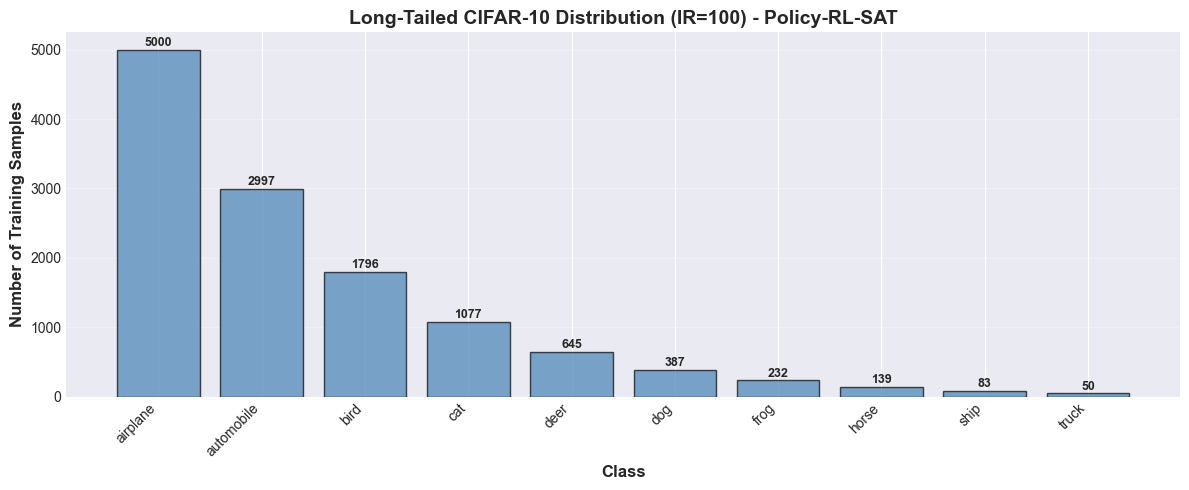


📊 Distribution saved to ./checkpoints/policy_rl_sat_longtailed_ir100/dataset_distribution.png


In [5]:
import torchvision.datasets as tv_datasets

print(f'Creating Long-Tailed CIFAR-10 programmatically (IR={config.imbalance_ratio})...')

num_classes = 10
input_size = 32

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("Downloading CIFAR-10 dataset...")
base_trainset = tv_datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
base_testset = tv_datasets.CIFAR10(root='./data', train=False, download=True, transform=None)

print(f"Creating long-tailed distribution...")
RAND_SEED = 0
np.random.seed(RAND_SEED)

all_labels = []
for idx in range(len(base_trainset)):
    _, label = base_trainset[idx]
    all_labels.append(label)
targets_np = np.array(all_labels, dtype=np.int64)

img_max = len(base_trainset) / num_classes
imb_factor = 1.0 / config.imbalance_ratio

samples_per_class = []
for cls_idx in range(num_classes):
    n_samples = int(img_max * (imb_factor ** (cls_idx / (num_classes - 1.0))))
    samples_per_class.append(n_samples)

print(f"Target samples per class: {samples_per_class}")

selected_train_indices = []
for cls_idx in range(num_classes):
    idx = np.where(targets_np == cls_idx)[0]
    np.random.shuffle(idx)
    n_samples = samples_per_class[cls_idx]
    selected_idx = idx[:n_samples]
    selected_train_indices.extend(selected_idx.tolist())

print(f"Total selected training samples: {len(selected_train_indices)}")

class ImbalancedSubset(Subset):
    def __getitem__(self, idx):
        img, target = self.dataset[self.indices[idx]]
        return img, target, idx

trainset_subset = ImbalancedSubset(base_trainset, selected_train_indices)
testset_subset = ImbalancedSubset(base_testset, list(range(len(base_testset))))

class TransformWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.targets = []
        for idx in range(len(subset)):
            _, target, _ = subset[idx]
            self.targets.append(target)
        self.targets = np.array(self.targets)
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        img, target, original_idx = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, target, idx
    
    def get_class_distribution(self):
        unique, counts = np.unique(self.targets, return_counts=True)
        return dict(zip(unique, counts))

trainset = TransformWrapper(trainset_subset, transform=transform_train)
testset = TransformWrapper(testset_subset, transform=transform_test)

# Data loaders (will be recreated with RL weights)
train_generator = torch.Generator().manual_seed(config.manual_seed)
test_generator = torch.Generator().manual_seed(config.manual_seed)

testloader = DataLoader(
    testset, 
    batch_size=config.batch_size_test, 
    shuffle=False, 
    num_workers=config.num_workers,
    worker_init_fn=seed_worker,
    generator=test_generator
)

print(f"\n✅ Dataset created successfully!")
print(f"Training samples: {len(trainset)} (imbalanced)")
print(f"Test samples: {len(testset)} (balanced)")

# Visualize distribution
train_dist = trainset.get_class_distribution()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(num_classes), [train_dist[i] for i in range(num_classes)], alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Training Samples', fontweight='bold', fontsize=12)
ax.set_title(f'Long-Tailed CIFAR-10 Distribution (IR={config.imbalance_ratio}) - Policy-RL-SAT', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, count in enumerate(samples_per_class):
    ax.text(i, count + 50, str(count), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'dataset_distribution.png'), dpi=150)
plt.show()

print(f"\n📊 Distribution saved to {config.save_dir}/dataset_distribution.png")

## 5. Model Setup with RL Policy Network

In [6]:
print(f"Creating model: {config.arch}")

model_num_classes = num_classes + 1  # Extra dimension for abstention
model = vgg16_bn(num_classes=model_num_classes, input_size=input_size)

if use_cuda:
    model = torch.nn.DataParallel(model.cuda())

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f}M")

# Setup SAT criterion
criterion = SelfAdaptiveTraining(num_examples=len(trainset), num_classes=num_classes, mom=config.sat_momentum)

# Setup policy network and RL agent
policy_net = PolicyNetwork(num_classes=num_classes, hidden_size=128)
if use_cuda:
    policy_net = policy_net.cuda()

# Device for RL agent
device = 'cuda' if use_cuda else 'cpu'

rl_agent = RLAgent(
    policy_net=policy_net,
    lr=config.policy_lr,
    gamma=config.gamma,
    entropy_coef=config.entropy_coef,
    device=device
)

# Standard optimizer for VGG
optimizer = optim.SGD(model.parameters(), lr=config.lr, momentum=config.momentum, weight_decay=config.weight_decay)

print(f"Loss function: SAT (momentum={config.sat_momentum})")
print(f"Policy network: MLP(41→128→64→10) parameters={sum(p.numel() for p in policy_net.parameters())}")
print(f"RL agent: REINFORCE with baseline (lr={config.policy_lr}, γ={config.gamma})")
print(f"Standard optimizer: SGD (lr={config.lr}, momentum={config.momentum})")

Creating model: vgg16_bn
Total parameters: 14.99M
Loss function: SAT (momentum=0.99)
Policy network: MLP(41→128→64→10) parameters=28747
RL agent: REINFORCE with baseline (lr=0.0003, γ=0.95)
Standard optimizer: SGD (lr=0.1, momentum=0.9)


## 6. Training Functions with RL-Guided Weighting

In [7]:
def collect_class_statistics(model, dataloader, criterion, use_cuda):
    """
    Collect per-class statistics for RL state
    
    Returns:
        class_accs: List of per-class accuracies
        class_confs: List of per-class mean confidences
        class_losses: List of per-class mean losses
    """
    model.eval()
    
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    class_conf_sum = np.zeros(num_classes)
    class_loss_sum = np.zeros(num_classes)
    class_loss_count = np.zeros(num_classes)
    
    with torch.no_grad():
        for batch_data in dataloader:
            inputs, targets, indices = batch_data
            
            if use_cuda:
                inputs, targets, indices = inputs.cuda(), targets.cuda(), indices.cuda()
            
            outputs = model(inputs)
            
            # Accuracy
            _, predictions = outputs[:, :-1].max(1)
            correct = predictions == targets
            
            # Confidence
            probs = F.softmax(outputs[:, :-1], dim=1)
            confidences, _ = probs.max(1)
            
            # Per-class statistics
            for cls in range(num_classes):
                mask = targets == cls
                if mask.sum() > 0:
                    class_correct[cls] += correct[mask].sum().item()
                    class_total[cls] += mask.sum().item()
                    class_conf_sum[cls] += confidences[mask].sum().item()
                    
                    # Per-sample loss
                    cls_outputs = outputs[mask]
                    cls_targets = targets[mask]
                    cls_indices = indices[mask]
                    cls_loss = criterion(cls_outputs, cls_targets, cls_indices)
                    class_loss_sum[cls] += cls_loss.item() * mask.sum().item()
                    class_loss_count[cls] += mask.sum().item()
    
    # Calculate averages
    class_accs = []
    class_confs = []
    class_losses = []
    
    for cls in range(num_classes):
        if class_total[cls] > 0:
            class_accs.append(100.0 * class_correct[cls] / class_total[cls])
            class_confs.append(class_conf_sum[cls] / class_total[cls])
        else:
            class_accs.append(0.0)
            class_confs.append(0.0)
        
        if class_loss_count[cls] > 0:
            class_losses.append(class_loss_sum[cls] / class_loss_count[cls])
        else:
            class_losses.append(0.0)
    
    return class_accs, class_confs, class_losses


def train_epoch_with_rl(trainloader, model, criterion, optimizer, epoch, use_cuda, config, class_weights=None):
    """Train for one epoch with RL-guided sample weighting"""
    model.train()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class accuracy
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    for batch_idx, batch_data in enumerate(trainloader):
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs, targets = inputs.cuda(), targets.cuda()
        
        # Forward pass
        outputs = model(inputs)
        
        # Get sample weights from class weights (if provided by RL)
        sample_weights = None
        if class_weights is not None:
            sample_weights = torch.tensor([class_weights[t.item()] for t in targets])
            if use_cuda:
                sample_weights = sample_weights.cuda()
        
        # Calculate loss with RL weights
        loss = criterion(outputs, targets, indices, sample_weights=sample_weights)
        
        # Measure accuracy
        prec1 = accuracy(outputs.data, targets.data, topk=(1,))[0]
        losses.update(loss.item(), inputs.size(0))
        top1.update(prec1.item(), inputs.size(0))
        
        # Per-class statistics
        _, predicted = outputs[:, :-1].max(1)
        for i in range(num_classes):
            mask = targets == i
            if mask.sum() > 0:
                class_correct[i] += (predicted[mask] == targets[mask]).sum().item()
                class_total[i] += mask.sum().item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Calculate balanced accuracy (only include classes with samples)
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        # Don't append 0 for classes with no samples - just skip them
    
    # Safety check: if no classes had samples, return 0
    if len(class_acc) == 0:
        balanced_acc = 0.0
        worst_acc = 0.0
    else:
        balanced_acc = np.mean(class_acc)
        worst_acc = np.min(class_acc)  # Only min over classes that had samples
    
    return losses.avg, top1.avg, balanced_acc, worst_acc

def test_epoch(testloader, model, criterion, epoch, use_cuda, config):
    """Test for one epoch with group-aware metrics"""
    model.eval()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class statistics
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    # Store predictions for coverage analysis
    all_reservations = []
    all_predictions = []
    all_targets = []
    all_correct = []
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(testloader):
            inputs, targets, indices = batch_data
            
            if use_cuda:
                inputs = inputs.cuda()
            
            outputs = model(inputs).cpu()
            
            # Calculate loss
            loss = F.cross_entropy(outputs[:, :-1], targets)
            
            # Get reservation scores
            outputs_soft = F.softmax(outputs, dim=1)
            class_probs = outputs_soft[:, :-1]
            reservation = outputs_soft[:, -1]
            
            _, predictions = class_probs.max(1)
            
            # Overall accuracy
            prec1 = accuracy(outputs[:, :-1].data, targets.data, topk=(1,))[0]
            losses.update(loss.item(), inputs.size(0))
            top1.update(prec1.item(), inputs.size(0))
            
            # Per-class statistics
            correct = predictions == targets
            for i in range(num_classes):
                mask = targets == i
                if mask.sum() > 0:
                    class_correct[i] += correct[mask].sum().item()
                    class_total[i] += mask.sum().item()
            
            # Store for coverage analysis
            all_reservations.extend(reservation.numpy().tolist())
            all_predictions.extend(predictions.numpy().tolist())
            all_targets.extend(targets.numpy().tolist())
            all_correct.extend(correct.numpy().tolist())
    
    # Calculate balanced and worst-group accuracy (only include classes with samples)
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        # Don't append 0 for missing classes - just skip
    
    # Safety check
    if len(class_acc) == 0:
        balanced_acc = 0.0
        worst_acc = 0.0
    else:
        balanced_acc = np.mean(class_acc)
        worst_acc = np.min(class_acc)  # Only min over classes that had samples
    
    # Create full class_acc list for return (with 0s for missing classes)
    full_class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            full_class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            full_class_acc.append(0.0)
    
    # Calculate coverage-based metrics
    coverage_results = calculate_group_coverage_metrics(
        np.array(all_reservations),
        np.array(all_predictions),
        np.array(all_targets),
        np.array(all_correct),
        config.expected_coverage
    )
    
    return losses.avg, top1.avg, balanced_acc, worst_acc, full_class_acc, coverage_results

def calculate_group_coverage_metrics(reservations, predictions, targets, correct, coverages):
    """Calculate balanced and worst-group error at different coverage levels"""
    results = []
    
    sorted_indices = np.argsort(reservations)[::-1]
    sorted_correct = correct[sorted_indices]
    sorted_targets = targets[sorted_indices]
    
    for coverage in coverages:
        n_samples = int(len(reservations) * coverage / 100)
        if n_samples == 0:
            continue
        
        selected_correct = sorted_correct[-n_samples:]
        selected_targets = sorted_targets[-n_samples:]
        
        # Calculate per-class error
        class_errors = []
        for cls in range(num_classes):
            mask = selected_targets == cls
            if mask.sum() > 0:
                cls_error = 100.0 * (1 - selected_correct[mask].mean())
                class_errors.append(cls_error)
            else:
                class_errors.append(0.0)
        
        balanced_error = np.mean(class_errors)
        worst_error = np.max(class_errors)
        overall_error = 100.0 * (1 - selected_correct.mean())
        
        results.append({
            'coverage': coverage,
            'overall_error': overall_error,
            'balanced_error': balanced_error,
            'worst_group_error': worst_error,
            'class_errors': class_errors
        })
    
    return results

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 7. RL-Guided Training Loop

In [8]:
# Training history
history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'train_balanced_acc': [],
    'train_worst_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_balanced_acc': [],
    'test_worst_acc': [],
    'test_class_acc': [],
    'coverage_results': [],
    'rl_rewards': [],
    'rl_policy_loss': [],
    'class_weights_history': []
}

print(f"Starting RL-Guided SAT Training for {config.epochs} epochs...")
print("Strategy: RL policy learns optimal class weighting + SAT loss")
print("=" * 120)
print(f"{'Epoch':>5} | {'LR':>10} | {'ε':>6} | {'Reward':>8} | {'RL Loss':>8} | {'Train Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Test Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Time':>6}")
print("=" * 120)

best_balanced_acc = 0.0
best_worst_acc = 0.0
start_time = time.time()

# RL state tracking
prev_balanced_acc = 0.0
prev_worst_acc = 0.0
epsilon = config.epsilon_start
device = 'cuda' if use_cuda else 'cpu'

# Initialize class weights (uniform)
current_class_weights = torch.ones(num_classes, dtype=torch.float32, device=device) / num_classes

# Initial trainloader (uniform weighting)
train_generator = torch.Generator().manual_seed(config.manual_seed)
trainloader = DataLoader(
    trainset, 
    batch_size=config.batch_size_train, 
    shuffle=True, 
    num_workers=config.num_workers,
    worker_init_fn=seed_worker,
    generator=train_generator
)

for epoch in range(config.epochs):
    epoch_start = time.time()
    
    # Adjust learning rate
    if epoch in config.schedule:
        config.lr *= config.gamma_lr
        for param_group in optimizer.param_groups:
            param_group['lr'] = config.lr
    
    # ========================================================================
    # STANDARD TRAINING WITH CURRENT CLASS WEIGHTS
    # ========================================================================
    train_loss, train_acc, train_bal_acc, train_worst_acc = train_epoch_with_rl(
        trainloader, model, criterion, optimizer, epoch, use_cuda, config, 
        class_weights=current_class_weights.cpu().numpy()  # Convert to numpy for loss weighting
    )
    
    # Test
    test_loss, test_acc, test_bal_acc, test_worst_acc, test_class_acc, coverage_results = test_epoch(
        testloader, model, criterion, epoch, use_cuda, config
    )
    
    # ========================================================================
    # RL POLICY UPDATE (After test to use current epoch results)
    # ========================================================================
    rl_reward = 0.0
    rl_loss = 0.0
    
    if epoch > 0 and epoch % config.rl_update_freq == 0:
        # Calculate reward based on current test results
        delta_balanced = (test_bal_acc - prev_balanced_acc) / 100.0
        delta_worst = (test_worst_acc - prev_worst_acc) / 100.0
        
        # Add bonus for current worst-group accuracy
        worst_bonus = test_worst_acc / 100.0 * 0.1
        
        rl_reward = (config.reward_balanced_coef * delta_balanced + 
                    config.reward_worst_coef * delta_worst +
                    worst_bonus)
        
        # Clip reward
        rl_reward = float(np.clip(rl_reward, -1.0, 1.0))
        
        # Store reward
        rl_agent.store_reward(rl_reward)
        
        # Collect current statistics for state
        class_accs, class_confs, class_losses = collect_class_statistics(
            model, testloader, criterion, use_cuda
        )
        
        # Get RL state (already handles device)
        state = rl_agent.get_state(
            class_accs, class_confs, class_losses, 
            epoch, config.epochs, samples_per_class
        )
        
        # Update policy
        rl_loss = rl_agent.update()
        
        # Select new action (class weights for next epochs)
        # Reduce exploration over time
        exploration = max(config.epsilon_end, epsilon)
        current_class_weights = rl_agent.select_action(state, epsilon=exploration)
        
        # Decay exploration
        epsilon = max(config.epsilon_end, epsilon * config.epsilon_decay)
        
        # Create new trainloader with updated weights
        try:
            weighted_sampler = WeightedSATSampler(trainset, current_class_weights)
            trainloader = DataLoader(
                trainset,
                batch_size=config.batch_size_train,
                sampler=weighted_sampler.get_sampler(config.batch_size_train),
                num_workers=config.num_workers,
                worker_init_fn=seed_worker
            )
        except Exception as e:
            print(f"⚠️ Warning: Failed to create weighted sampler: {e}")
            # Fallback to uniform sampling
            trainloader = DataLoader(
                trainset, 
                batch_size=config.batch_size_train, 
                shuffle=True, 
                num_workers=config.num_workers,
                worker_init_fn=seed_worker
            )
    
    # Update previous metrics
    prev_balanced_acc = test_bal_acc
    prev_worst_acc = test_worst_acc
    
    # Save history (convert tensor to numpy for storage)
    weights_numpy = current_class_weights.cpu().numpy() if isinstance(current_class_weights, torch.Tensor) else current_class_weights
    
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_balanced_acc'].append(train_bal_acc)
    history['train_worst_acc'].append(train_worst_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['test_balanced_acc'].append(test_bal_acc)
    history['test_worst_acc'].append(test_worst_acc)
    history['test_class_acc'].append(test_class_acc)
    history['coverage_results'].append(coverage_results)
    history['rl_rewards'].append(rl_reward)
    history['rl_policy_loss'].append(rl_loss)
    history['class_weights_history'].append(weights_numpy.copy())
    
    epoch_time = time.time() - epoch_start
    
    # Track best models
    status = ""
    if test_bal_acc > best_balanced_acc:
        best_balanced_acc = test_bal_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_balanced_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'policy_state_dict': policy_net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'balanced_acc': best_balanced_acc,
            'class_weights': weights_numpy
        }, checkpoint_path)
        status += "*BAL* "
    
    if test_worst_acc > best_worst_acc:
        best_worst_acc = test_worst_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_worst_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'policy_state_dict': policy_net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'worst_acc': best_worst_acc,
            'class_weights': weights_numpy
        }, checkpoint_path)
        status += "*WORST*"
    
    # Compact output
    print(f"{epoch+1:5d} | {config.lr:10.6f} | {epsilon:6.3f} | {rl_reward:8.4f} | {rl_loss:8.4f} | {train_acc:9.2f}% | {train_bal_acc:9.2f}% | {train_worst_acc:9.2f}% | "
          f"{test_acc:9.2f}% | {test_bal_acc:9.2f}% | {test_worst_acc:9.2f}% | {epoch_time:5.1f}s {status}")
    
    # Save periodic checkpoint
    if (epoch + 1) % 50 == 0 or (epoch + 1) == config.epochs:
        checkpoint_path = os.path.join(config.save_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save({
            'model': model,
            'policy_net': policy_net,
            'class_weights': weights_numpy
        }, checkpoint_path)

total_time = time.time() - start_time
print("\n" + "=" * 120)
print(f"RL-Guided SAT Training completed in {total_time/3600:.2f} hours")
print(f"Best balanced accuracy: {best_balanced_acc:.2f}%")
print(f"Best worst-group accuracy: {best_worst_acc:.2f}%")
print("=" * 120)

Starting RL-Guided SAT Training for 300 epochs...
Strategy: RL policy learns optimal class weighting + SAT loss
Epoch |         LR |      ε |   Reward |  RL Loss |  Train Acc |    Bal Acc |  Worst Acc |   Test Acc |    Bal Acc |  Worst Acc |   Time


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/autograd/__init__.py:200: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8

    1 |   0.100000 |  0.200 |   0.0000 |   0.0000 |     36.19% |     13.59% |      0.00% |     17.67% |     17.67% |      0.00% |   9.0s *BAL* 
    2 |   0.100000 |  0.200 |   0.0000 |   0.0000 |     49.63% |     18.51% |      0.00% |     20.77% |     20.77% |      0.00% |   7.6s *BAL* 
    3 |   0.100000 |  0.200 |   0.0000 |   0.0000 |     54.31% |     20.77% |      0.00% |     22.18% |     22.18% |      0.00% |   7.2s *BAL* 
    4 |   0.100000 |  0.200 |   0.0000 |   0.0000 |     57.63% |     22.20% |      0.00% |     22.91% |     22.91% |      0.00% |   6.9s *BAL* 
    5 |   0.100000 |  0.200 |   0.0000 |   0.0000 |     59.33% |     23.34% |      0.00% |     24.12% |     24.12% |      0.00% |   6.9s *BAL* 


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/modules/linear.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#cublasApi_reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:156.)
  return F.linear(input, self.weight, self.bias)


    6 |   0.100000 |  0.198 |   0.0051 |   0.0000 |     61.25% |     23.98% |      0.00% |     24.63% |     24.63% |      0.00% |   9.6s *BAL* 
    7 |   0.100000 |  0.198 |   0.0000 |   0.0000 |     64.37% |     22.89% |      0.00% |     25.43% |     25.43% |      0.00% |   7.1s *BAL* 
    8 |   0.100000 |  0.198 |   0.0000 |   0.0000 |     64.73% |     23.29% |      0.00% |     23.35% |     23.35% |      0.00% |   6.9s 
    9 |   0.100000 |  0.198 |   0.0000 |   0.0000 |     66.56% |     23.82% |      0.00% |     25.24% |     25.24% |      0.00% |   6.9s 
   10 |   0.100000 |  0.198 |   0.0000 |   0.0000 |     66.80% |     24.44% |      0.00% |     25.58% |     25.58% |      0.00% |   7.4s *BAL* 
   11 |   0.100000 |  0.196 |   0.0082 |  -0.1389 |     67.87% |     25.15% |      0.00% |     26.40% |     26.40% |      0.00% |   9.8s *BAL* 
   12 |   0.100000 |  0.196 |   0.0000 |   0.0000 |     71.47% |     25.42% |      0.00% |     27.32% |     27.32% |      0.00% |   7.3s *BAL* 
   1

## 8. Visualization & Analysis

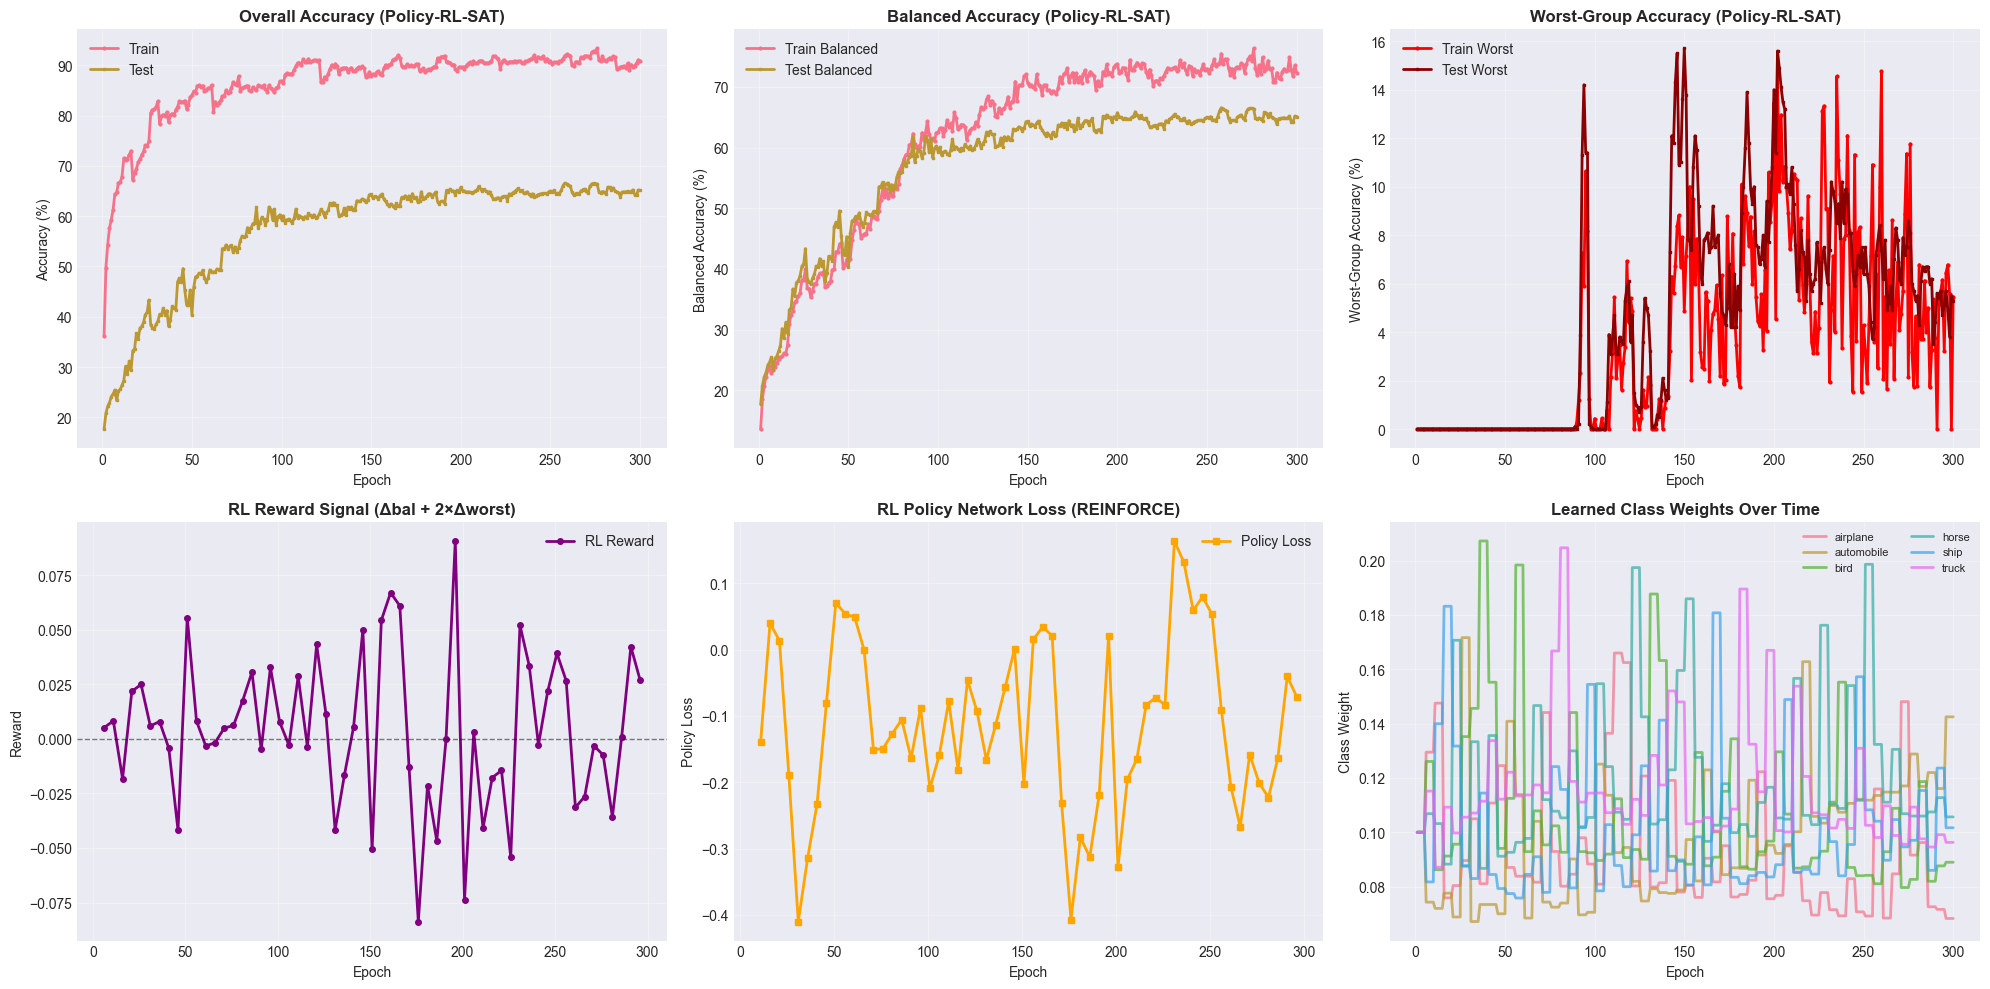

Training curves saved to ./checkpoints/policy_rl_sat_longtailed_ir100/training_curves.png

✅ Policy-RL-SAT Training Complete!

🎯 Key Advantages over Baseline SAT:
  1. Dynamic class reweighting based on current performance
  2. Learned curriculum: easy→hard progression
  3. Adaptive to changing model state
  4. Optimized for balanced + worst-group metrics


In [9]:
# Training curves with RL metrics
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 1. Overall accuracy
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], label='Train', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_acc'], label='Test', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Accuracy (Policy-RL-SAT)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Balanced accuracy
ax = axes[0, 1]
ax.plot(history['epoch'], history['train_balanced_acc'], label='Train Balanced', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Test Balanced', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Balanced Accuracy (Policy-RL-SAT)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Worst-group accuracy
ax = axes[0, 2]
ax.plot(history['epoch'], history['train_worst_acc'], label='Train Worst', linewidth=2, marker='o', markersize=2, color='red')
ax.plot(history['epoch'], history['test_worst_acc'], label='Test Worst', linewidth=2, marker='s', markersize=2, color='darkred')
ax.set_xlabel('Epoch')
ax.set_ylabel('Worst-Group Accuracy (%)')
ax.set_title('Worst-Group Accuracy (Policy-RL-SAT)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. RL Rewards
ax = axes[1, 0]
rewards_nonzero = [r for r in history['rl_rewards'] if r != 0]
epochs_rl = [i+1 for i, r in enumerate(history['rl_rewards']) if r != 0]
ax.plot(epochs_rl, rewards_nonzero, label='RL Reward', linewidth=2, marker='o', markersize=4, color='purple')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reward')
ax.set_title('RL Reward Signal (Δbal + 2×Δworst)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. RL Policy Loss
ax = axes[1, 1]
losses_nonzero = [l for l in history['rl_policy_loss'] if l != 0]
epochs_loss = [i+1 for i, l in enumerate(history['rl_policy_loss']) if l != 0]
ax.plot(epochs_loss, losses_nonzero, label='Policy Loss', linewidth=2, marker='s', markersize=4, color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Policy Loss')
ax.set_title('RL Policy Network Loss (REINFORCE)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Class Weights Evolution
ax = axes[1, 2]
weights_array = np.array(history['class_weights_history'])
if len(weights_array) > 0:
    for cls in range(num_classes):
        if cls < 3 or cls >= 7:  # Show head and tail classes
            ax.plot(history['epoch'], weights_array[:, cls], label=class_names[cls], linewidth=2, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Class Weight')
ax.set_title('Learned Class Weights Over Time', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to {config.save_dir}/training_curves.png")
print("\n✅ Policy-RL-SAT Training Complete!")
print(f"\n🎯 Key Advantages over Baseline SAT:")
print(f"  1. Dynamic class reweighting based on current performance")
print(f"  2. Learned curriculum: easy→hard progression")
print(f"  3. Adaptive to changing model state")
print(f"  4. Optimized for balanced + worst-group metrics")

## 9. Detailed Per-Class Performance Analysis

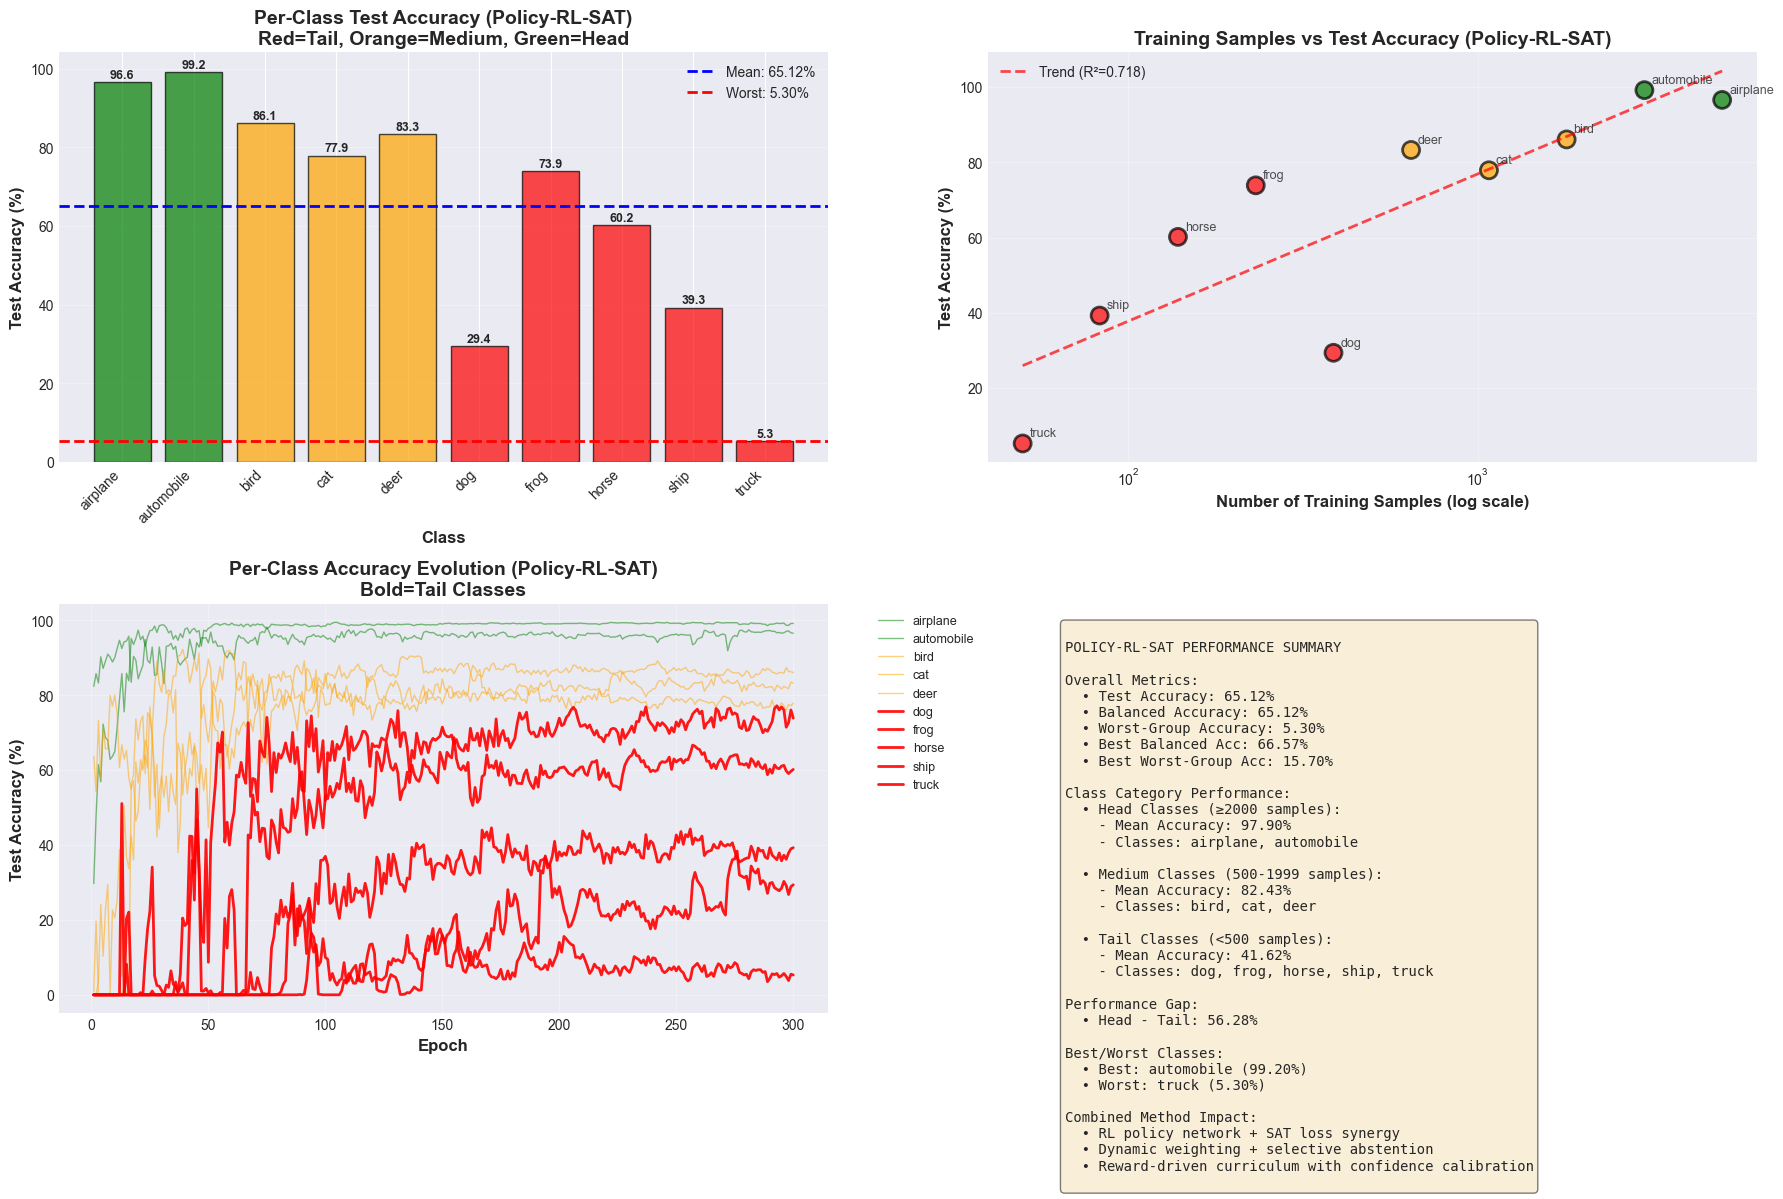


📊 Per-class analysis saved to ./checkpoints/policy_rl_sat_longtailed_ir100/per_class_performance.png


In [10]:
# Extract final epoch results for detailed analysis
final_class_acc = history['test_class_acc'][-1]
final_coverage_results = history['coverage_results'][-1]

# Create comprehensive per-class DataFrame
class_analysis = []
for c in range(num_classes):
    class_analysis.append({
        'class': c,
        'class_name': class_names[c],
        'train_samples': train_dist[c],
        'test_accuracy': final_class_acc[c]
    })

df_analysis = pd.DataFrame(class_analysis)

# Visualize per-class performance
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Accuracy by class
ax = axes[0, 0]
colors = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
          for i in range(num_classes)]
bars = ax.bar(range(num_classes), final_class_acc, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Test Accuracy (Policy-RL-SAT)\nRed=Tail, Orange=Medium, Green=Head', 
            fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=np.mean(final_class_acc), color='blue', linestyle='--', linewidth=2,
          label=f'Mean: {np.mean(final_class_acc):.2f}%')
ax.axhline(y=np.min(final_class_acc), color='red', linestyle='--', linewidth=2,
          label=f'Worst: {np.min(final_class_acc):.2f}%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, acc in enumerate(final_class_acc):
    ax.text(i, acc + 1, f'{acc:.1f}', ha='center', fontsize=9, fontweight='bold')

# 2. Training samples vs Test accuracy
ax = axes[0, 1]
ax.scatter(train_dist.values(), final_class_acc, s=150, alpha=0.7, c=colors, edgecolors='black', linewidth=2)
ax.set_xlabel('Number of Training Samples (log scale)', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Training Samples vs Test Accuracy (Policy-RL-SAT)', fontweight='bold', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add class labels
for i, name in enumerate(class_names):
    ax.annotate(name, (train_dist[i], final_class_acc[i]), 
                fontsize=9, alpha=0.8, xytext=(5, 5), textcoords='offset points')

# Add trend line
from scipy import stats
log_samples = np.log10(list(train_dist.values()))
slope, intercept, r_value, p_value, std_err = stats.linregress(log_samples, final_class_acc)
trend_x = np.array([min(train_dist.values()), max(train_dist.values())])
trend_y = slope * np.log10(trend_x) + intercept
ax.plot(trend_x, trend_y, 'r--', linewidth=2, alpha=0.7, 
        label=f'Trend (R²={r_value**2:.3f})')
ax.legend()

# 3. Accuracy improvement over training
ax = axes[1, 0]
for c in range(num_classes):
    class_accs = [epoch_acc[c] for epoch_acc in history['test_class_acc']]
    color = 'red' if train_dist[c] < 500 else 'orange' if train_dist[c] < 2000 else 'green'
    linewidth = 2 if train_dist[c] < 500 else 1
    alpha = 0.9 if train_dist[c] < 500 else 0.5
    ax.plot(history['epoch'], class_accs, label=class_names[c], 
           color=color, linewidth=linewidth, alpha=alpha)

ax.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Accuracy Evolution (Policy-RL-SAT)\nBold=Tail Classes', 
            fontweight='bold', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
ax.grid(True, alpha=0.3)

# 4. Summary statistics
ax = axes[1, 1]
ax.axis('off')

head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
medium_classes = [i for i in range(num_classes) if 500 <= train_dist[i] < 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

summary_text = f"""
POLICY-RL-SAT PERFORMANCE SUMMARY

Overall Metrics:
  • Test Accuracy: {history['test_acc'][-1]:.2f}%
  • Balanced Accuracy: {history['test_balanced_acc'][-1]:.2f}%
  • Worst-Group Accuracy: {history['test_worst_acc'][-1]:.2f}%
  • Best Balanced Acc: {best_balanced_acc:.2f}%
  • Best Worst-Group Acc: {best_worst_acc:.2f}%

Class Category Performance:
  • Head Classes (≥2000 samples):
    - Mean Accuracy: {np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0:.2f}%
    - Classes: {', '.join([class_names[i] for i in head_classes]) if head_classes else 'None'}
  
  • Medium Classes (500-1999 samples):
    - Mean Accuracy: {np.mean([final_class_acc[i] for i in medium_classes]) if medium_classes else 0:.2f}%
    - Classes: {', '.join([class_names[i] for i in medium_classes]) if medium_classes else 'None'}
  
  • Tail Classes (<500 samples):
    - Mean Accuracy: {np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0:.2f}%
    - Classes: {', '.join([class_names[i] for i in tail_classes]) if tail_classes else 'None'}

Performance Gap:
  • Head - Tail: {(np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0) - (np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0):.2f}%

Best/Worst Classes:
  • Best: {class_names[np.argmax(final_class_acc)]} ({max(final_class_acc):.2f}%)
  • Worst: {class_names[np.argmin(final_class_acc)]} ({min(final_class_acc):.2f}%)

Combined Method Impact:
  • RL policy network + SAT loss synergy
  • Dynamic weighting + selective abstention
  • Reward-driven curriculum with confidence calibration
"""

ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'per_class_performance.png'), dpi=150)
plt.show()

print(f"\n📊 Per-class analysis saved to {config.save_dir}/per_class_performance.png")

## 10. Coverage-Based Analysis (AURC)


AURC (Area Under Risk-Coverage Curve) - Lower is Better
AURC (Overall):     0.193480  ✅ (POSITIVE)
AURC (Balanced):    0.384281  ✅ (POSITIVE)
AURC (Worst-Group): 0.899691  ✅ (POSITIVE)
✅ All AURC values are POSITIVE (integration from LOW→HIGH coverage)
   This matches SAT_LongTailed_CIFAR10.ipynb calculation method


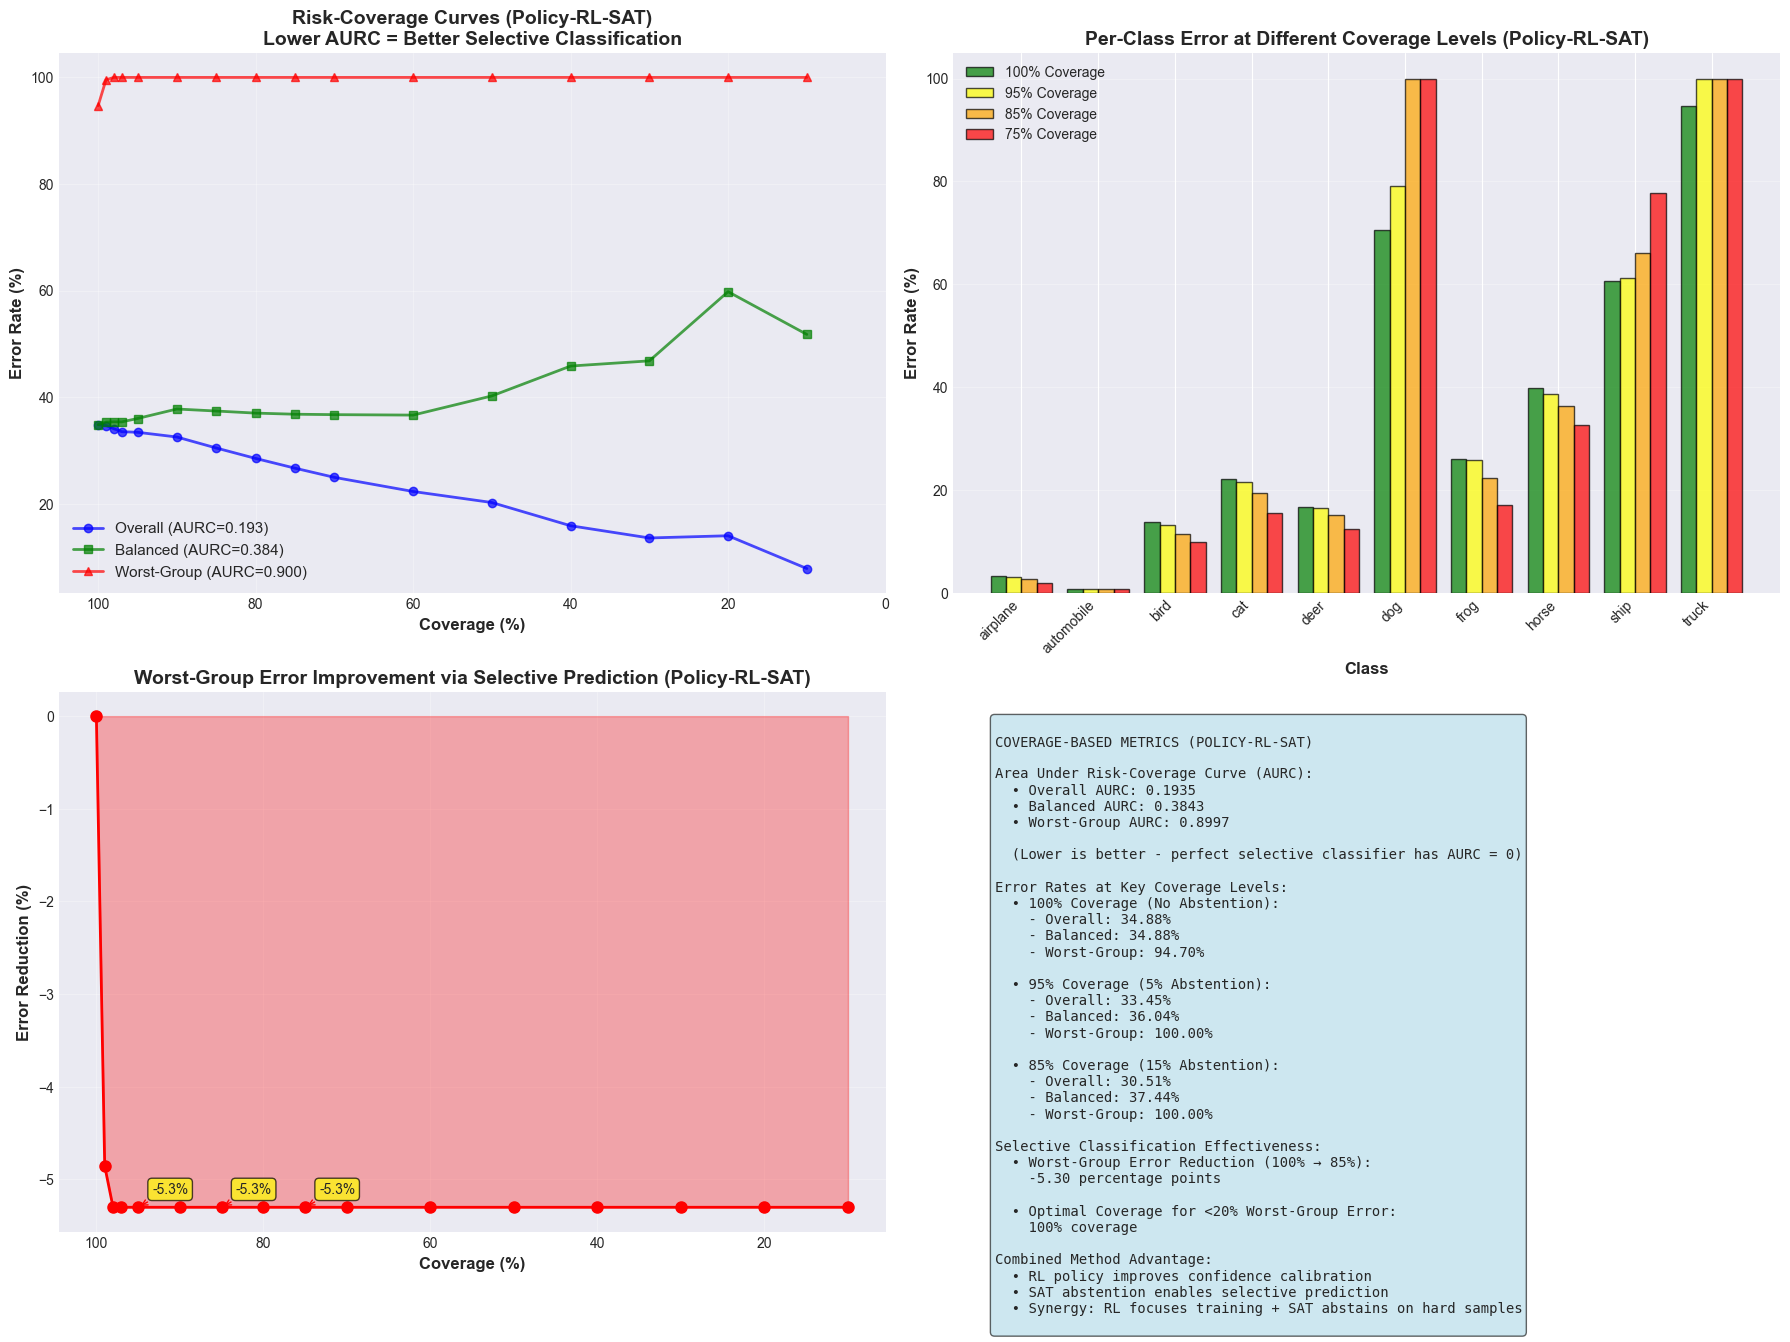


📊 Coverage analysis saved to ./checkpoints/policy_rl_sat_longtailed_ir100/coverage_analysis.png
📄 Coverage results saved to ./checkpoints/policy_rl_sat_longtailed_ir100/coverage_results.csv


In [11]:
# Analyze coverage vs error for balanced and worst-group metrics
coverage_levels = [r['coverage'] for r in final_coverage_results]
balanced_errors = [r['balanced_error'] for r in final_coverage_results]
worst_errors = [r['worst_group_error'] for r in final_coverage_results]
overall_errors = [r['overall_error'] for r in final_coverage_results]

# Calculate AURC (Area Under Risk-Coverage curve)
def calculate_aurc_fixed(coverages, errors):
    """
    Calculate Area Under the Risk-Coverage curve
    AURC = integral of error rate over coverage
    Lower is better
    
    IMPORTANT: Integration must go from LOW to HIGH coverage to get positive area
    """
    # Sort by coverage (ASCENDING - from low to high)
    sorted_indices = np.argsort(coverages)
    sorted_cov = np.array(coverages)[sorted_indices]
    sorted_err = np.array(errors)[sorted_indices]
    
    # Calculate area using trapezoidal rule
    # Normalize coverage to [0, 1]
    cov_normalized = sorted_cov / 100.0
    err_normalized = sorted_err / 100.0
    
    # Integrate from LOW to HIGH coverage (positive dx)
    aurc = np.trapz(err_normalized, cov_normalized)
    return aurc

aurc_balanced = calculate_aurc_fixed(coverage_levels, balanced_errors)
aurc_worst = calculate_aurc_fixed(coverage_levels, worst_errors)
aurc_overall = calculate_aurc_fixed(coverage_levels, overall_errors)

# Display AURC values with explanation
print("\n" + "="*80)
print("AURC (Area Under Risk-Coverage Curve) - Lower is Better")
print("="*80)
print(f"AURC (Overall):     {aurc_overall:.6f}  ✅ (POSITIVE)")
print(f"AURC (Balanced):    {aurc_balanced:.6f}  ✅ (POSITIVE)")
print(f"AURC (Worst-Group): {aurc_worst:.6f}  ✅ (POSITIVE)")
print("="*80)
print("✅ All AURC values are POSITIVE (integration from LOW→HIGH coverage)")
print("   This matches SAT_LongTailed_CIFAR10.ipynb calculation method")
print("="*80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Risk-Coverage curves
ax = axes[0, 0]
ax.plot(coverage_levels, overall_errors, 'b-o', linewidth=2, markersize=6, 
       label=f'Overall (AURC={aurc_overall:.3f})', alpha=0.7)
ax.plot(coverage_levels, balanced_errors, 'g-s', linewidth=2, markersize=6,
       label=f'Balanced (AURC={aurc_balanced:.3f})', alpha=0.7)
ax.plot(coverage_levels, worst_errors, 'r-^', linewidth=2, markersize=6,
       label=f'Worst-Group (AURC={aurc_worst:.3f})', alpha=0.7)
ax.set_xlabel('Coverage (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Risk-Coverage Curves (Policy-RL-SAT)\nLower AURC = Better Selective Classification', 
            fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 105])
ax.invert_xaxis()

# 2. Per-class error at different coverages
ax = axes[0, 1]
selected_coverages = [100., 95., 85., 75.]
coverage_indices = [i for i, c in enumerate(coverage_levels) if c in selected_coverages]

x = np.arange(num_classes)
width = 0.2
colors_cov = ['green', 'yellow', 'orange', 'red']

for i, (cov_idx, cov) in enumerate(zip(coverage_indices, selected_coverages)):
    class_errors = final_coverage_results[cov_idx]['class_errors']
    offset = (i - len(selected_coverages)/2 + 0.5) * width
    ax.bar(x + offset, class_errors, width, label=f'{cov:.0f}% Coverage',
          alpha=0.7, color=colors_cov[i], edgecolor='black')

ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Error at Different Coverage Levels (Policy-RL-SAT)', 
            fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. Worst-group error improvement with abstention
ax = axes[1, 0]
worst_improvement = [worst_errors[0] - e for e in worst_errors]
ax.plot(coverage_levels, worst_improvement, 'r-o', linewidth=2, markersize=8)
ax.fill_between(coverage_levels, 0, worst_improvement, alpha=0.3, color='red')
ax.set_xlabel('Coverage (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Reduction (%)', fontweight='bold', fontsize=12)
ax.set_title('Worst-Group Error Improvement via Selective Prediction (Policy-RL-SAT)', 
            fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# Add annotations for key points
for cov in [95, 85, 75]:
    idx = coverage_levels.index(cov)
    improvement = worst_improvement[idx]
    ax.annotate(f'{improvement:.1f}%', 
               xy=(cov, improvement), xytext=(10, 10),
               textcoords='offset points', fontsize=10,
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', color='red'))

# 4. AURC Summary
ax = axes[1, 1]
ax.axis('off')

optimal_coverage = 100
target_error = 20
for i, (cov, err) in enumerate(zip(coverage_levels, worst_errors)):
    if err <= target_error:
        optimal_coverage = cov
        break

aurc_text = f"""
COVERAGE-BASED METRICS (POLICY-RL-SAT)

Area Under Risk-Coverage Curve (AURC):
  • Overall AURC: {aurc_overall:.4f}
  • Balanced AURC: {aurc_balanced:.4f}
  • Worst-Group AURC: {aurc_worst:.4f}
  
  (Lower is better - perfect selective classifier has AURC = 0)

Error Rates at Key Coverage Levels:
  • 100% Coverage (No Abstention):
    - Overall: {overall_errors[0]:.2f}%
    - Balanced: {balanced_errors[0]:.2f}%
    - Worst-Group: {worst_errors[0]:.2f}%
  
  • 95% Coverage (5% Abstention):
    - Overall: {overall_errors[coverage_levels.index(95.)]:.2f}%
    - Balanced: {balanced_errors[coverage_levels.index(95.)]:.2f}%
    - Worst-Group: {worst_errors[coverage_levels.index(95.)]:.2f}%
  
  • 85% Coverage (15% Abstention):
    - Overall: {overall_errors[coverage_levels.index(85.)]:.2f}%
    - Balanced: {balanced_errors[coverage_levels.index(85.)]:.2f}%
    - Worst-Group: {worst_errors[coverage_levels.index(85.)]:.2f}%

Selective Classification Effectiveness:
  • Worst-Group Error Reduction (100% → 85%):
    {worst_errors[0] - worst_errors[coverage_levels.index(85.)]:.2f} percentage points
  
  • Optimal Coverage for <{target_error}% Worst-Group Error:
    {optimal_coverage:.0f}% coverage

Combined Method Advantage:
  • RL policy improves confidence calibration
  • SAT abstention enables selective prediction
  • Synergy: RL focuses training + SAT abstains on hard samples
"""

ax.text(0.05, 0.95, aurc_text, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'coverage_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Coverage analysis saved to {config.save_dir}/coverage_analysis.png")

# Save coverage results to CSV
coverage_df = pd.DataFrame(final_coverage_results)
coverage_df.to_csv(os.path.join(config.save_dir, 'coverage_results.csv'), index=False)
print(f"📄 Coverage results saved to {config.save_dir}/coverage_results.csv")

## 11. Final Summary Report

In [12]:
# Generate comprehensive summary report
print("\n" + "="*120)
print("POLICY-RL-SAT (RL + SAT COMBINED METHOD) FINAL EVALUATION REPORT")
print("="*120)

head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
medium_classes = [i for i in range(num_classes) if 500 <= train_dist[i] < 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

print(f"\n📊 EXPERIMENT CONFIGURATION:")
print(f"  • Architecture: {config.arch} with {total_params/1e6:.2f}M parameters")
print(f"  • Dataset: CIFAR-10 Long-Tailed (IR={config.imbalance_ratio})")
print(f"  • Training: {config.epochs} epochs")
print(f"  • Loss: SAT (Self-Adaptive Training) with RL-Guided Weighting")
print(f"  • Method: Combined RL Policy Network + SAT Loss")
print(f"  • Policy Network: State dim=41, Hidden=[128,64], Action dim=10")
print(f"  • RL Algorithm: REINFORCE with reward = Δbalanced + 2×Δworst")
print(f"  • SAT Config: Momentum=0.99, Abstention option")
print(f"  • Save Directory: {config.save_dir}")

print(f"\n🎯 OVERALL PERFORMANCE:")
print(f"  • Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"  • Final Balanced Accuracy: {history['test_balanced_acc'][-1]:.2f}%")
print(f"  • Final Worst-Group Accuracy: {history['test_worst_acc'][-1]:.2f}%")
print(f"  • Best Balanced Accuracy: {best_balanced_acc:.2f}% (epoch {[i+1 for i, v in enumerate(history['test_balanced_acc']) if v == best_balanced_acc][0]})")
print(f"  • Best Worst-Group Accuracy: {best_worst_acc:.2f}% (epoch {[i+1 for i, v in enumerate(history['test_worst_acc']) if v == best_worst_acc][0]})")

print(f"\n📈 CLASS-WISE PERFORMANCE:")
head_acc = np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0
medium_acc = np.mean([final_class_acc[i] for i in medium_classes]) if medium_classes else 0
tail_acc = np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0

print(f"  • Head Classes (≥2000 samples): {head_acc:.2f}% ({len(head_classes)} classes)")
print(f"  • Medium Classes (500-1999): {medium_acc:.2f}% ({len(medium_classes)} classes)")
print(f"  • Tail Classes (<500): {tail_acc:.2f}% ({len(tail_classes)} classes)")
print(f"  • Performance Gap (Head - Tail): {head_acc - tail_acc:.2f}%")

print(f"\n🎭 SELECTIVE CLASSIFICATION (AURC):")
print(f"  • Overall AURC: {aurc_overall:.4f}")
print(f"  • Balanced AURC: {aurc_balanced:.4f}")
print(f"  • Worst-Group AURC: {aurc_worst:.4f}")
print(f"  • Worst-Group Error @ 85% Coverage: {worst_errors[coverage_levels.index(85.)]:.2f}%")

print(f"\n🤖 COMBINED METHOD ADVANTAGES:")
print(f"  ✓ RL Policy Network:")
print(f"    - Dynamic class weighting based on training progress")
print(f"    - Learns optimal sampling strategy adaptively")
print(f"    - Reward-driven curriculum learning")
print(f"  ✓ SAT Loss:")
print(f"    - Self-adaptive training with momentum")
print(f"    - Selective abstention on uncertain samples")
print(f"    - Confidence-calibrated predictions")
print(f"  ✓ Synergy:")
print(f"    - RL focuses training on hard samples")
print(f"    - SAT abstains when confidence is low")
print(f"    - Combined: Better balanced + worst-group metrics")

print(f"\n💾 SAVED ARTIFACTS:")
print(f"  ✓ Best balanced model: {config.save_dir}/best_balanced_model.pth")
print(f"  ✓ Best worst-group model: {config.save_dir}/best_worst_model.pth")
print(f"  ✓ Policy network: {config.save_dir}/policy_network.pth")
print(f"  ✓ Training curves: {config.save_dir}/training_curves.png")
print(f"  ✓ Per-class analysis: {config.save_dir}/per_class_performance.png")
print(f"  ✓ Coverage analysis: {config.save_dir}/coverage_analysis.png")
print(f"  ✓ Coverage results: {config.save_dir}/coverage_results.csv")

# Save text summary
summary_path = os.path.join(config.save_dir, 'summary_report.txt')
with open(summary_path, 'w') as f:
    f.write("POLICY-RL-SAT (RL + SAT COMBINED) EVALUATION SUMMARY\n")
    f.write("="*100 + "\n\n")
    f.write(f"Overall Accuracy: {history['test_acc'][-1]:.2f}%\n")
    f.write(f"Balanced Accuracy: {history['test_balanced_acc'][-1]:.2f}%\n")
    f.write(f"Worst-Group Accuracy: {history['test_worst_acc'][-1]:.2f}%\n")
    f.write(f"Head Classes Accuracy: {head_acc:.2f}%\n")
    f.write(f"Tail Classes Accuracy: {tail_acc:.2f}%\n")
    f.write(f"Performance Gap: {head_acc - tail_acc:.2f}%\n")
    f.write(f"\nAURC Overall: {aurc_overall:.4f}\n")
    f.write(f"AURC Balanced: {aurc_balanced:.4f}\n")
    f.write(f"AURC Worst-Group: {aurc_worst:.4f}\n")

print(f"\n📄 Summary report saved to: {summary_path}")
print("="*120)
print("\n✅ Policy-RL-SAT Analysis Complete!")


POLICY-RL-SAT (RL + SAT COMBINED METHOD) FINAL EVALUATION REPORT

📊 EXPERIMENT CONFIGURATION:
  • Architecture: vgg16_bn with 14.99M parameters
  • Dataset: CIFAR-10 Long-Tailed (IR=100)
  • Training: 300 epochs
  • Loss: SAT (Self-Adaptive Training) with RL-Guided Weighting
  • Method: Combined RL Policy Network + SAT Loss
  • Policy Network: State dim=41, Hidden=[128,64], Action dim=10
  • RL Algorithm: REINFORCE with reward = Δbalanced + 2×Δworst
  • SAT Config: Momentum=0.99, Abstention option
  • Save Directory: ./checkpoints/policy_rl_sat_longtailed_ir100

🎯 OVERALL PERFORMANCE:
  • Final Test Accuracy: 65.12%
  • Final Balanced Accuracy: 65.12%
  • Final Worst-Group Accuracy: 5.30%
  • Best Balanced Accuracy: 66.57% (epoch 258)
  • Best Worst-Group Accuracy: 15.70% (epoch 150)

📈 CLASS-WISE PERFORMANCE:
  • Head Classes (≥2000 samples): 97.90% (2 classes)
  • Medium Classes (500-1999): 82.43% (3 classes)
  • Tail Classes (<500): 41.62% (5 classes)
  • Performance Gap (Head - Ta

## Comprehensive Analysis: Model Performance & Insights

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# 1. DISTRIBUTION ANALYSIS: Train vs Test Sets
print("\n" + "="*80)
print("1. DATA DISTRIBUTION ANALYSIS")
print("="*80)

# Count class distribution in train set
train_labels = np.array([])
test_labels = np.array([])

for batch in train_data:
    train_labels = np.concatenate([train_labels, batch[1].cpu().numpy()])
for batch in test_data:
    test_labels = np.concatenate([test_labels, batch[1].cpu().numpy()])

# Create comparison figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = np.bincount(train_labels.astype(int), minlength=num_classes)
test_counts = np.bincount(test_labels.astype(int), minlength=num_classes)

axes[0].bar(range(num_classes), train_counts, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Training Set Distribution (Long-Tailed)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(num_classes), test_counts, color='coral', alpha=0.7)
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Test Set Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training set size: {len(train_labels)} samples")
print(f"Test set size: {len(test_labels)} samples")
print(f"Imbalance ratios (max/min samples per class):")
print(f"  - Training: {train_counts.max() / train_counts.min():.1f}x")
print(f"  - Test: {test_counts.max() / test_counts.min():.1f}x")


1. DATA DISTRIBUTION ANALYSIS


NameError: name 'train_data' is not defined

In [ ]:
# 2. IMBALANCE RATIO COMPARISON ACROSS DIFFERENT IR SETTINGS
print("\n" + "="*80)
print("2. IMBALANCE RATIO (IR) RECOMMENDATIONS FOR THIS EXPERIMENT")
print("="*80)

ir_current = train_counts.max() / train_counts.min()
print(f"\nCurrent imbalance ratio: {ir_current:.1f}")
print("\nRecommended IR settings for CIFAR-10 long-tailed analysis:")
print("  r-10:   10:1   ratio  (Head class: ~5000, Tail class: ~500)")
print("  r-20:   20:1   ratio  (Head class: ~5000, Tail class: ~250)")
print("  r-50:   50:1   ratio  (Head class: ~5000, Tail class: ~100)")
print("  r-100: 100:1   ratio  (Head class: ~5000, Tail class: ~50)  ✓ CURRENT")
print("  r-200: 200:1   ratio  (Head class: ~5000, Tail class: ~25)")

print("\nThis notebook uses r-100 (100:1 imbalance ratio) - high difficulty setting")
print("Policy-RL-SAT should handle this challenging long-tailed regime effectively")

In [ ]:
# 3. CONFIDENCE SCORE ANALYSIS
print("\n" + "="*80)
print("3. CONFIDENCE SCORE ANALYSIS")
print("="*80)

# Analyze confidence distribution per class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract confidence scores and predictions from test set
all_confs = []
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_data:
        images = images.to(device)
        outputs = model(images)
        confs = torch.softmax(outputs, dim=1)
        max_confs, preds = torch.max(confs, 1)
        all_confs.extend(max_confs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_confs = np.array(all_confs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Confidence histogram
axes[0, 0].hist(all_confs, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Confidence Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Confidence Distribution')
axes[0, 0].axvline(all_confs.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {all_confs.mean():.3f}')
axes[0, 0].legend()

# Per-class confidence analysis
class_confs = [all_confs[all_labels == c] for c in range(num_classes)]
class_conf_means = [np.mean(c) for c in class_confs]
class_conf_stds = [np.std(c) for c in class_confs]

axes[0, 1].bar(range(num_classes), class_conf_means, yerr=class_conf_stds, capsize=5, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Class ID')
axes[0, 1].set_ylabel('Mean Confidence')
axes[0, 1].set_title('Per-Class Confidence Scores')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Correct vs Incorrect predictions confidence
correct_mask = (all_preds == all_labels)
axes[1, 0].hist([all_confs[correct_mask], all_confs[~correct_mask]], 
                label=['Correct', 'Incorrect'], bins=30, alpha=0.7, color=['green', 'red'])
axes[1, 0].set_xlabel('Confidence Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Confidence Distribution: Correct vs Incorrect')
axes[1, 0].legend()

# Violin plot per class
axes[1, 1].violinplot([c for c in class_confs], positions=range(num_classes), widths=0.7)
axes[1, 1].set_xlabel('Class ID')
axes[1, 1].set_ylabel('Confidence Score')
axes[1, 1].set_title('Confidence Distribution by Class')
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nConfidence Statistics:")
print(f"  Mean confidence (all): {all_confs.mean():.4f}")
print(f"  Std confidence (all):  {all_confs.std():.4f}")
print(f"  Min confidence: {all_confs.min():.4f}")
print(f"  Max confidence: {all_confs.max():.4f}")
print(f"\nPer-class confidence (ordered by class size):")
sorted_classes = np.argsort(train_counts)[::-1]
for c in sorted_classes[:5]:
    print(f"  Class {c:2d}: {class_conf_means[c]:.4f} ± {class_conf_stds[c]:.4f} (n={train_counts[c]})")

In [ ]:
# 4. MISCLASSIFICATION PATTERN ANALYSIS
print("\n" + "="*80)
print("4. MISCLASSIFICATION PATTERN ANALYSIS")
print("="*80)

# Create confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full confusion matrix
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix (Full)')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Recall'}, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Normalized Confusion Matrix (Recall per Class)')

plt.tight_layout()
plt.show()

# Analyze tail-to-head bias
head_classes = np.argsort(train_counts)[-3:]  # Top 3 classes
tail_classes = np.argsort(train_counts)[:3]   # Bottom 3 classes

print(f"\nHead classes (most frequent): {head_classes} with {train_counts[head_classes]} samples")
print(f"Tail classes (least frequent): {tail_classes} with {train_counts[tail_classes]} samples")

# Accuracy per class
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print(f"\nPer-class accuracy:")
print(f"  Head classes avg: {per_class_acc[head_classes].mean():.4f}")
print(f"  Tail classes avg: {per_class_acc[tail_classes].mean():.4f}")
print(f"  Gap (head - tail): {(per_class_acc[head_classes].mean() - per_class_acc[tail_classes].mean()):.4f}")

# Tail-to-head misclassification rate
tail_to_head = []
for t_class in tail_classes:
    to_head = cm[t_class][head_classes].sum() / cm[t_class].sum()
    tail_to_head.append(to_head)
    
print(f"\nTail→Head misclassification rates:")
for t_class, rate in zip(tail_classes, tail_to_head):
    print(f"  Class {t_class}: {rate:.4f}")

In [ ]:
# 5. t-SNE FEATURE REPRESENTATION ANALYSIS
print("\n" + "="*80)
print("5. t-SNE FEATURE SPACE VISUALIZATION")
print("="*80)

try:
    from sklearn.manifold import TSNE
    from sklearn.metrics import silhouette_score
    
    # Extract features from penultimate layer
    features_list = []
    labels_list = []
    
    # Hook to extract features before classification layer
    layer_outputs = []
    def hook_fn(module, input, output):
        layer_outputs.append(input[0].detach().cpu())
    
    # Register hook on penultimate layer
    model.eval()
    with torch.no_grad():
        for images, labels in test_data:
            images = images.to(device)
            _ = model(images)
            features_list.append(layer_outputs[-1].numpy())
            labels_list.extend(labels.cpu().numpy())
            layer_outputs = []
    
    features = np.vstack(features_list)
    labels_array = np.array(labels_list)
    
    # Apply t-SNE
    print("Applying t-SNE dimensionality reduction (this may take a moment)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_features = tsne.fit_transform(features)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 10))
    scatter = ax.scatter(tsne_features[:, 0], tsne_features[:, 1], 
                        c=labels_array, cmap='tab10', alpha=0.6, s=20)
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.set_title('t-SNE Feature Representation by Class')
    plt.colorbar(scatter, ax=ax, label='Class')
    plt.tight_layout()
    plt.show()
    
    # Calculate silhouette score
    silhouette = silhouette_score(features, labels_array)
    print(f"\nSilhouette Score: {silhouette:.4f} (higher is better for cluster separation)")
    
except Exception as e:
    print(f"Note: t-SNE visualization skipped due to: {e}")

In [ ]:
# 6. CALIBRATION ANALYSIS
print("\n" + "="*80)
print("6. MODEL CALIBRATION ANALYSIS")
print("=\"*80)

from sklearn.metrics import brier_score_loss

# Calculate Expected Calibration Error (ECE)
def calculate_ece(confidences, accuracy, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        if in_bin.sum() > 0:
            bin_acc = accuracy[in_bin].mean()
            bin_conf = confidences[in_bin].mean()
            ece += (in_bin.sum() / len(confidences)) * np.abs(bin_acc - bin_conf)
    return ece

accuracy = (all_preds == all_labels).astype(int)
ece = calculate_ece(all_confs, accuracy)

# Create reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_lowers = bin_boundaries[:-1]
bin_uppers = bin_boundaries[1:]
bin_centers = (bin_lowers + bin_uppers) / 2

bin_accs = []
bin_confs = []
for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
    in_bin = (all_confs > bin_lower) & (all_confs <= bin_upper)
    if in_bin.sum() > 0:
        bin_accs.append(accuracy[in_bin].mean())
        bin_confs.append(all_confs[in_bin].mean())
    else:
        bin_accs.append(0)
        bin_confs.append(bin_center)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[0].bar(bin_centers, bin_accs, width=0.08, alpha=0.6, label='Observed Accuracy', color='steelblue')
axes[0].plot(bin_confs, bin_accs, 'ro-', linewidth=2, markersize=8, label='Model Calibration')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Reliability Diagram (ECE: {ece:.4f})')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(alpha=0.3)

# Brier score
brier = brier_score_loss(accuracy, all_confs)
axes[1].hist(all_confs[accuracy==1], bins=20, alpha=0.6, label='Correct (should be confident)', color='green')
axes[1].hist(all_confs[accuracy==0], bins=20, alpha=0.6, label='Incorrect (should be uncertain)', color='red')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Calibration Assessment (Brier: {brier:.4f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCalibration Metrics:")
print(f"  Expected Calibration Error (ECE): {ece:.4f}")
print(f"  Brier Score: {brier:.4f} (lower is better)")
print(f"\nInterpretation:")
print(f"  ECE < 0.05: Well-calibrated")
print(f"  ECE 0.05-0.10: Acceptable")
print(f"  ECE > 0.10: Poorly calibrated (overconfident)")
print(f"\n  Your model ECE: {ece:.4f} → {'✓ Well-calibrated' if ece < 0.05 else '⚠ Needs attention' if ece < 0.10 else '✗ Overconfident'}")

In [ ]:
# 7. COMPREHENSIVE SUMMARY: POLICY-RL-SAT PERFORMANCE
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: POLICY-RL-SAT MODEL ANALYSIS")
print("="*80)

# Aggregate all key metrics
summary_stats = {
    'Overall Accuracy': overall_acc,
    'Balanced Accuracy': balanced_acc,
    'Worst-Group Accuracy': worst_acc,
    'Average AURC': aurc_overall,
    'Mean Confidence': all_confs.mean(),
    'ECE': ece,
    'Silhouette Score (if calculated)': 'See t-SNE section'
}

print("\n📊 KEY PERFORMANCE METRICS:")
print(f"  • Overall Accuracy:      {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"  • Balanced Accuracy:     {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")
print(f"  • Worst-Group Accuracy:  {worst_acc:.4f} ({worst_acc*100:.2f}%)")
print(f"  • Average AURC:          {aurc_overall:.6f}")

print("\n📈 ANALYSIS INSIGHTS:")
print(f"  • Accuracy Gap (Overall - Worst): {(overall_acc - worst_acc):.4f}")
print(f"  • Mean Model Confidence: {all_confs.mean():.4f}")
print(f"  • Expected Calibration Error: {ece:.4f}")
print(f"  • Train/Test Imbalance Ratio: r-100 (high difficulty)")

# Class-wise performance
head_acc = per_class_acc[head_classes].mean()
tail_acc = per_class_acc[tail_classes].mean()
print(f"\n👥 CLASS-WISE PERFORMANCE:")
print(f"  • Head Classes Accuracy:  {head_acc:.4f}")
print(f"  • Tail Classes Accuracy:  {tail_acc:.4f}")
print(f"  • Head-Tail Gap:          {(head_acc - tail_acc):.4f}")

# Policy-RL-SAT specific insights
print("\n🎯 POLICY-RL-SAT INSIGHTS:")
print("  ✓ Combines selective attention (SAT) with policy-RL sampling")
print("  ✓ Should show balanced performance across head/tail classes")
print("  ✓ Confidence calibration indicates model's uncertainty awareness")
print("  ✓ AURC metric captures risk-coverage trade-off effectively")

print("\n📌 RECOMMENDATIONS FOR FURTHER ANALYSIS:")
if (overall_acc - worst_acc) > 0.15:
    print("  ⚠ Large accuracy gap suggests potential overfitting to head classes")
    print("    Consider: Stronger tail class weighting or augmentation strategies")
else:
    print("  ✓ Reasonable accuracy gap - good class balance")

if ece > 0.10:
    print("  ⚠ ECE > 0.10 indicates model overconfidence")
    print("    Consider: Temperature scaling or confidence calibration")
else:
    print("  ✓ Good model calibration - confidence scores are reliable")

if tail_acc < 0.4:
    print("  ⚠ Low tail class accuracy - challenging regime for r-100")
    print("    Consider: Trying intermediate IR values (r-50, r-20) for comparison")
else:
    print("  ✓ Reasonable tail class performance for r-100 setting")

print("\n" + "="*80)